<a href="https://colab.research.google.com/github/toobajaved/GraphBasedMovieRecommendation/blob/main/02_Graph_Construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = '/content/drive/MyDrive/MLG Project/Project'

BASE = '/content/drive/MyDrive/MLG Project/Project'
DATA_RAW = f'{BASE}/data/raw'
DATA_PROCESSED = f'{BASE}/data/processed'
FIGURES = f'{BASE}/results/figures'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
ratings = pd.read_csv(f'{DATA_RAW}/ratings.csv')
movies = pd.read_csv(f'{DATA_RAW}/movies.csv')


In [27]:
import networkx as nx
from networkx.algorithms import bipartite

# Filter positive interactions
positive_ratings = ratings[ratings['rating'] >= 4.0]

# Create bipartite graph
G = nx.Graph()

# Add nodes with type attribute
user_nodes = [f"user_{uid}" for uid in positive_ratings['userId'].unique()]
movie_nodes = [f"movie_{mid}" for mid in positive_ratings['movieId'].unique()]

G.add_nodes_from(user_nodes, bipartite='user')
G.add_nodes_from(movie_nodes, bipartite='movie')

# Add edges
edges = [(f"user_{row.userId}", f"movie_{row.movieId}", {'weight': row.rating})
         for row in positive_ratings.itertuples()]
G.add_weighted_edges_from(edges)

print(f"Total nodes: {G.number_of_nodes()}")
print(f"  User nodes:  {len(user_nodes)}")
print(f"  Movie nodes: {len(movie_nodes)}")
print(f"Total edges:   {G.number_of_edges()}")

Total nodes: 6907
  User nodes:  609
  Movie nodes: 6298
Total edges:   48580


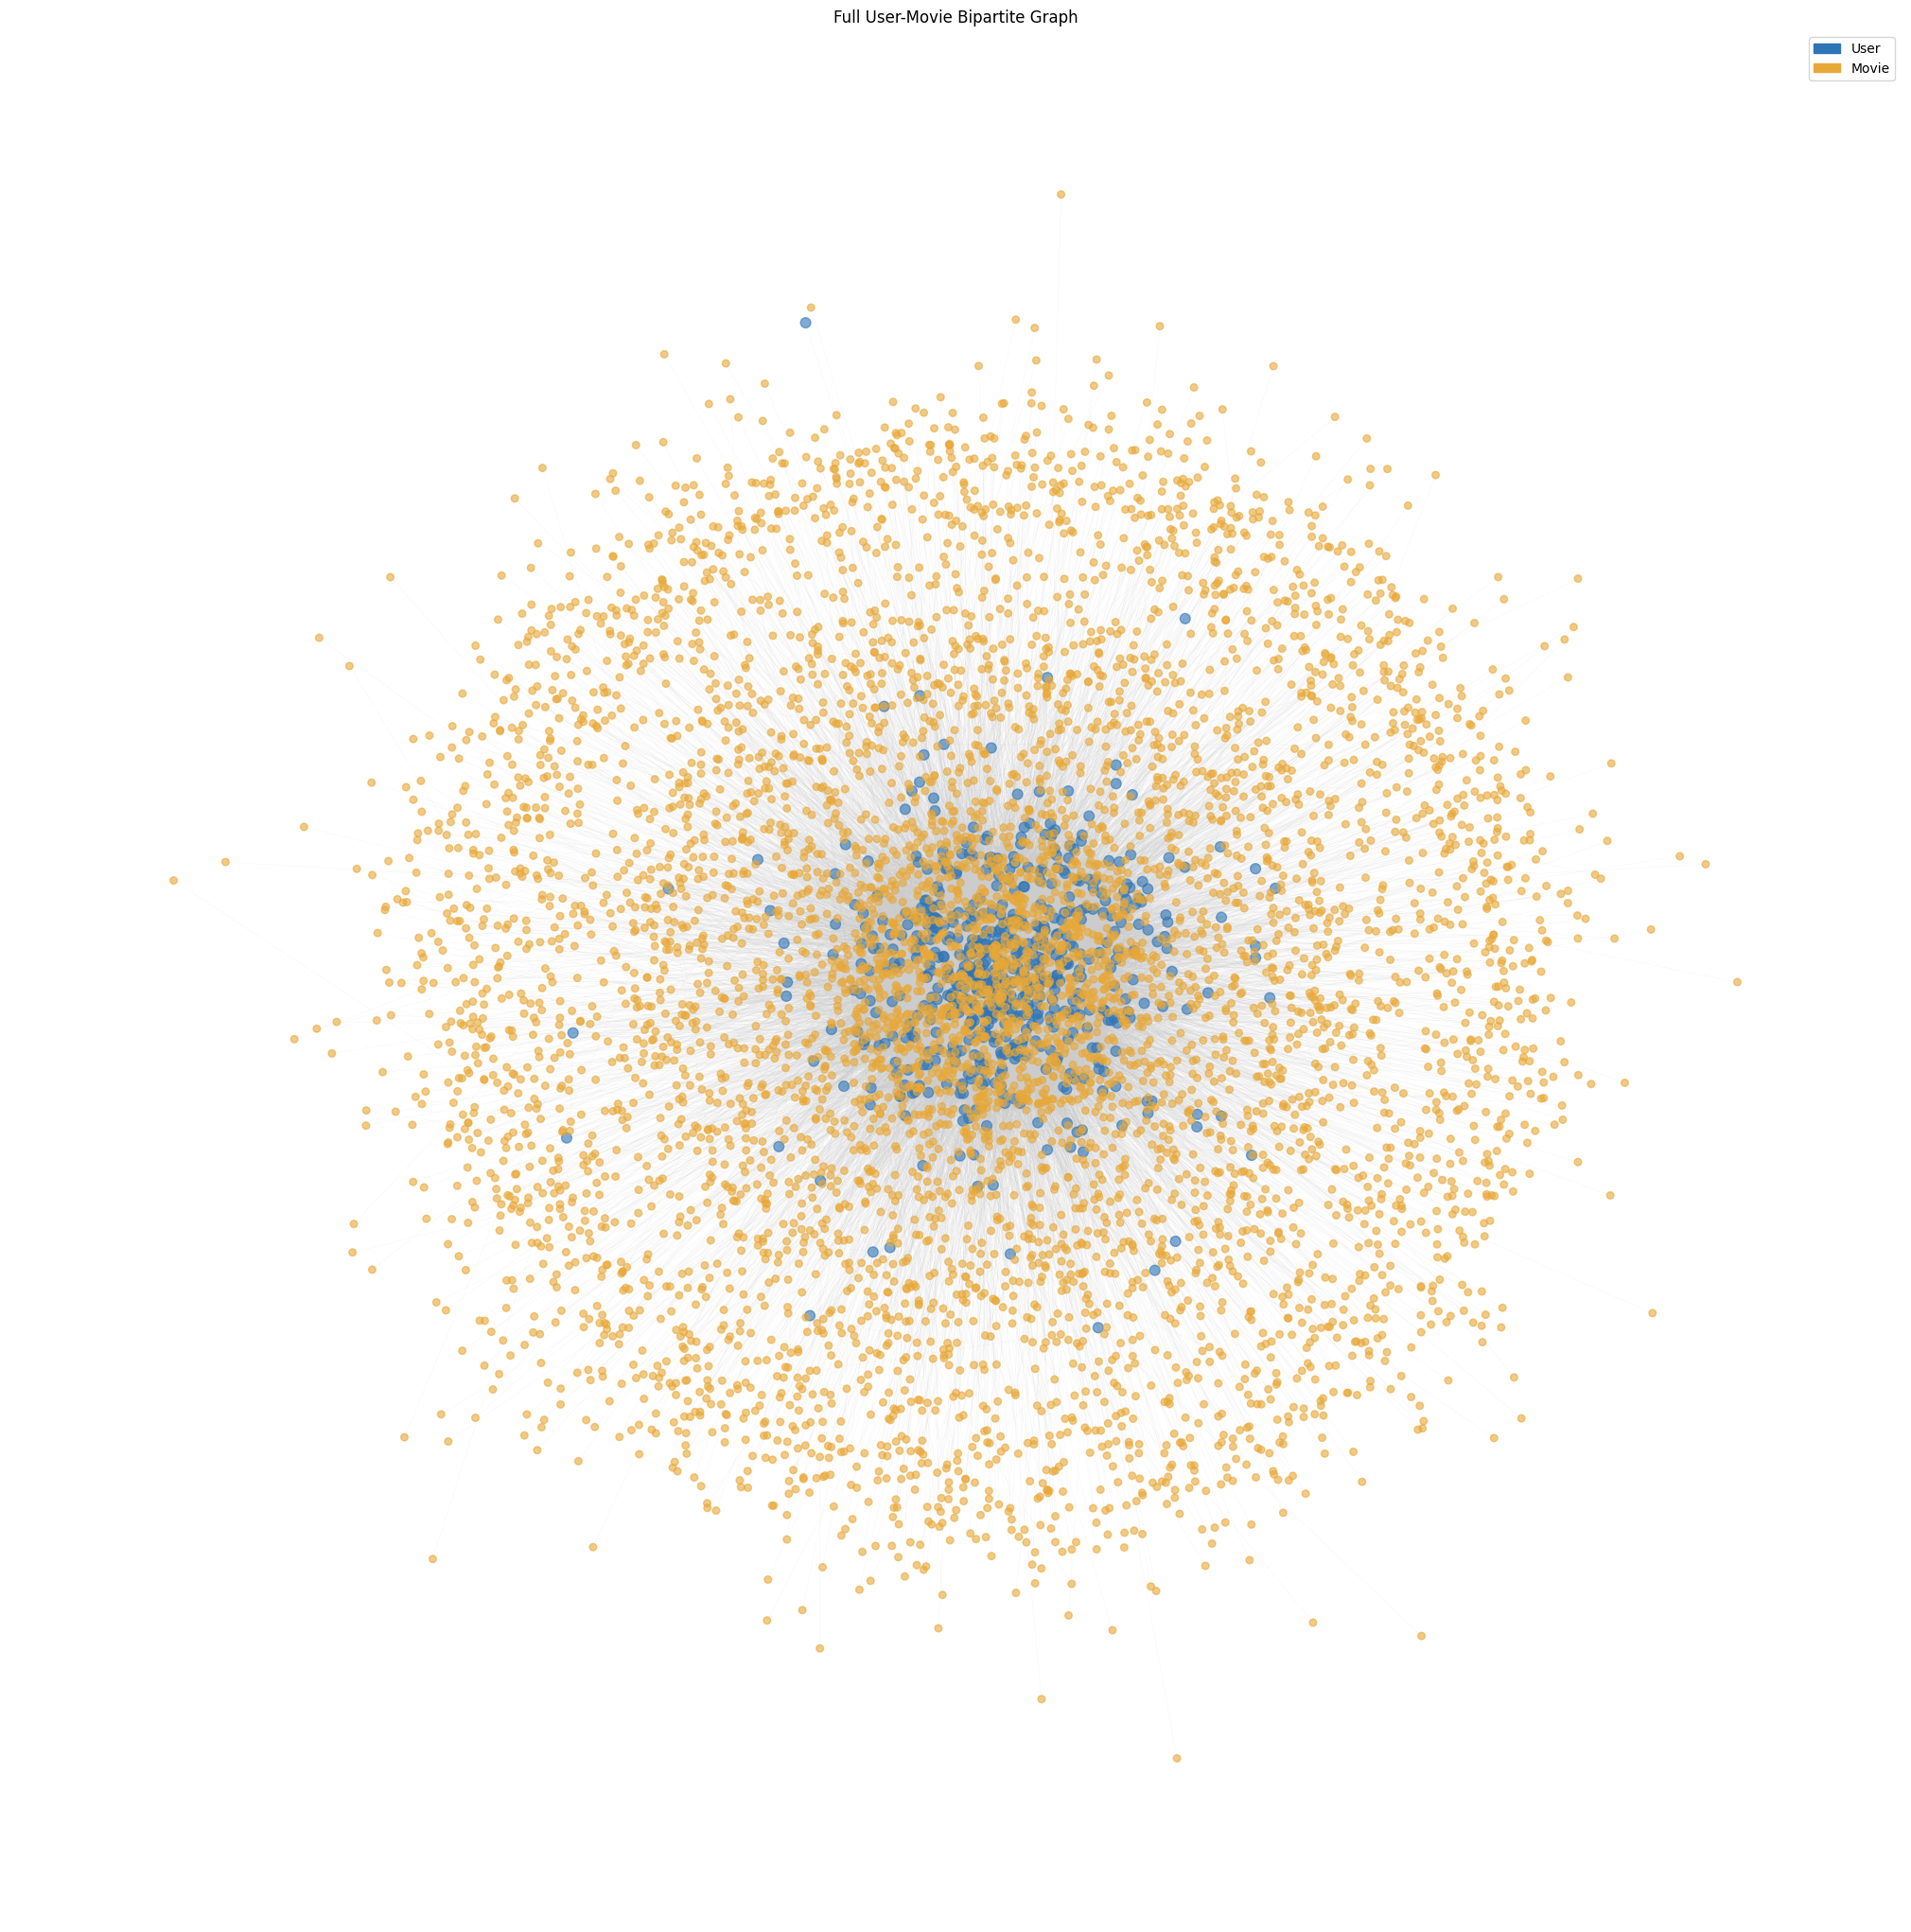

In [28]:
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, seed=42, k=0.1, weight=None)
nx.draw(G, pos,
        node_color=['#2E75B6' if G.nodes[n]['bipartite'] == 'user' else '#E8A838' for n in G.nodes()],
        node_size=[30 if G.nodes[n]['bipartite'] == 'movie' else 60 for n in G.nodes()],
        edge_color='#CCCCCC', width=0.1, with_labels=False, alpha=0.6)

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#2E75B6', label='User'), Patch(color='#E8A838', label='Movie')], markerscale=2)
plt.title('Full User-Movie Bipartite Graph')
plt.savefig(f'{FIGURES}/milestone2_full_graph.png', dpi=100)
plt.show()

In [ ]:
#Graph Statistics
user_degrees = [d for n, d in G.degree() if G.nodes[n]['bipartite'] == 'user']
movie_degrees = [d for n, d in G.degree() if G.nodes[n]['bipartite'] == 'movie']

print(f"Avg degree (users):  {sum(user_degrees)/len(user_degrees):.2f}")
print(f"Avg degree (movies): {sum(movie_degrees)/len(movie_degrees):.2f}")
print(f"Graph density: {nx.density(G):.6f}")
print(f"Is bipartite: {bipartite.is_bipartite(G)}")

Avg degree (users):  79.77
Avg degree (movies): 7.71
Graph density: 0.002037
Is bipartite: True


/tmp/ipykernel_179/3942989144.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


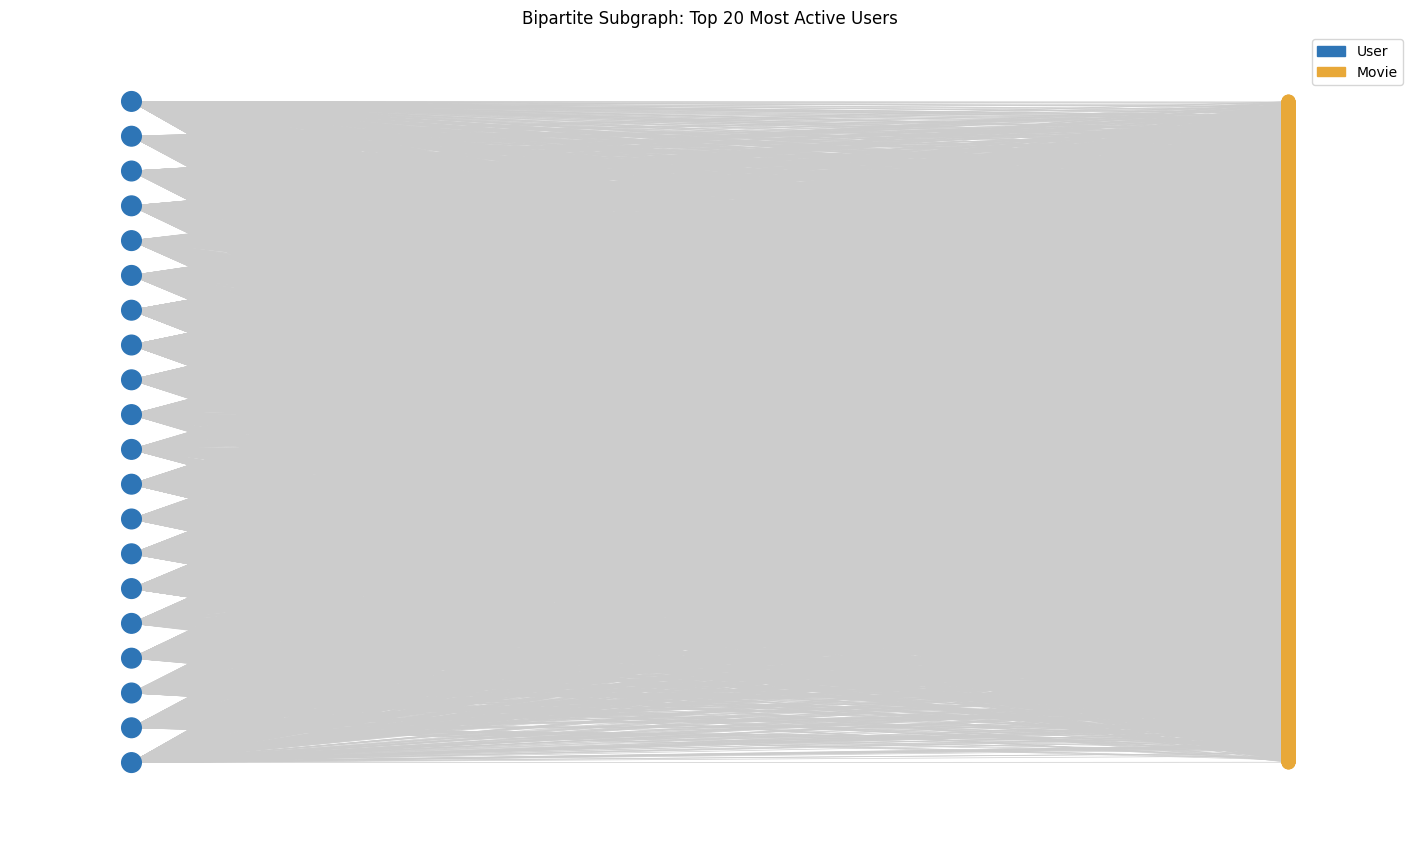

In [29]:
# Subgraph Visualization
top_users = positive_ratings.groupby('userId').size().nlargest(20).index
top_user_nodes = [f"user_{uid}" for uid in top_users]

connected_movies = [n for u in top_user_nodes for n in G.neighbors(u)]
subgraph_nodes = top_user_nodes + connected_movies
sub = G.subgraph(subgraph_nodes)

plt.figure(figsize=(14, 8))
pos = nx.bipartite_layout(sub, top_user_nodes)
nx.draw(sub, pos,
        node_color=['#2E75B6' if G.nodes[n]['bipartite'] == 'user' else '#E8A838' for n in sub.nodes()],
        node_size=[80 if G.nodes[n]['bipartite'] == 'movie' else 200 for n in sub.nodes()],
        edge_color='#CCCCCC', width=0.5, with_labels=False)

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#2E75B6', label='User'), Patch(color='#E8A838', label='Movie')])
plt.title('Bipartite Subgraph: Top 20 Most Active Users')
plt.tight_layout()
plt.savefig(f'{FIGURES}/milestone2_subgraph.png', dpi=150)
plt.show()

/tmp/ipykernel_179/2019278271.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(15, 'rating'))
/tmp/ipykernel_179/2019278271.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


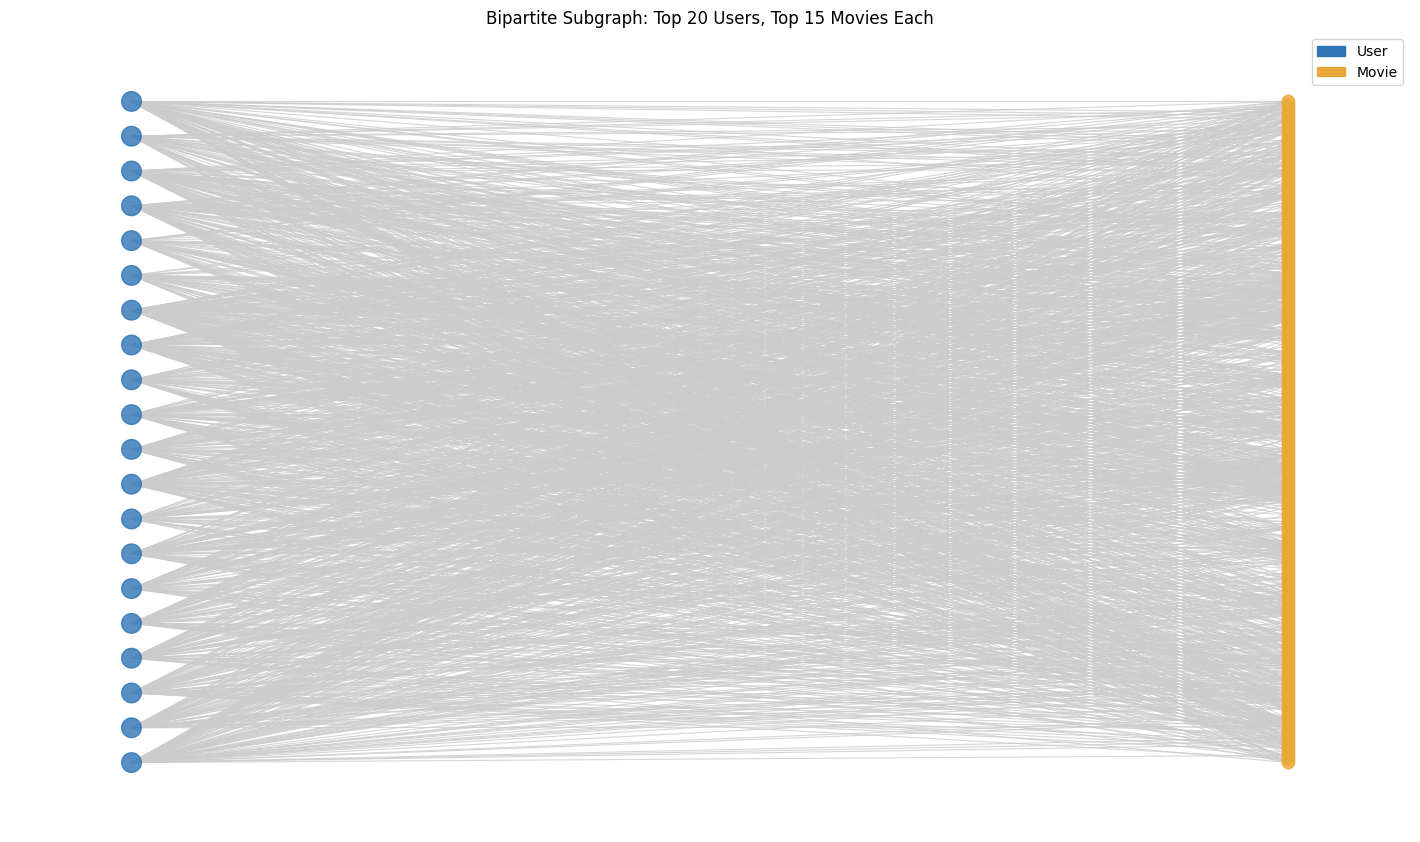

In [30]:
top_users = positive_ratings.groupby('userId').size().nlargest(20).index
top_user_nodes = [f"user_{uid}" for uid in top_users]

limited_edges = (positive_ratings[positive_ratings['userId'].isin(top_users)]
                 .groupby('userId')
                 .apply(lambda x: x.nlargest(15, 'rating'))
                 .reset_index(drop=True))

movie_nodes_sub = [f"movie_{mid}" for mid in limited_edges['movieId'].unique()]
sub = G.subgraph(top_user_nodes + movie_nodes_sub)

plt.figure(figsize=(14, 8))
pos = nx.bipartite_layout(sub, top_user_nodes)
nx.draw(sub, pos,
        node_color=['#2E75B6' if G.nodes[n]['bipartite'] == 'user' else '#E8A838' for n in sub.nodes()],
        node_size=[200 if G.nodes[n]['bipartite'] == 'user' else 80 for n in sub.nodes()],
        edge_color='#CCCCCC', width=0.8, with_labels=False, alpha=0.8)

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#2E75B6', label='User'), Patch(color='#E8A838', label='Movie')])
plt.title('Bipartite Subgraph: Top 20 Users, Top 15 Movies Each')
plt.tight_layout()
plt.savefig(f'{FIGURES}/milestone2_bipartite_subgraph_top20users_top15movies.png', dpi=150)
plt.show()